In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

In [107]:
df = pd.read_csv(r"C:\Users\Vijay_k943wj6\Desktop\datascience\python\Notes\Data Analyse\Data\Netflix Dataset.csv")

In [108]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


* #### It's a Data about the Netflix Shows.
* #### It Contain Shows_Id - An Unique Id.
* #### Category - Which Type of Category (Movie or Tv Show)
* #### Title - Name of that show or Movie.
* #### Director's Name - Director Name of that Particular show.
* #### Cast - Actors Name Which Acts on the Particular Show.
* #### Country - Which Country's Show.
* #### Release_Date - Which shows the Release Date of the Show.
* #### Rating - How much Rating It gets after people Watching show.
* #### Duration - Which Represent the Duration/ Time of that Show / Movie.
* #### Type - It means the Genre of that Movie.
* #### Description - Basic Plot of that Movie / Show.

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [110]:
df.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

In [111]:
df['Director'] = df['Director'].fillna('Unknown')

In [112]:
df['Cast'] = df['Cast'].fillna('Unknown')
df['Country'] = df['Country'].fillna('Unknown')
df['Rating'] = df['Rating'].fillna('Unknown')
df['Release_Date'] = df['Release_Date'].fillna('Unknown')

In [113]:
df.isna().sum()

Show_Id         0
Category        0
Title           0
Director        0
Cast            0
Country         0
Release_Date    0
Rating          0
Duration        0
Type            0
Description     0
dtype: int64

In [114]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors = 'coerce')

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Show_Id       7789 non-null   object        
 1   Category      7789 non-null   object        
 2   Title         7789 non-null   object        
 3   Director      7789 non-null   object        
 4   Cast          7789 non-null   object        
 5   Country       7789 non-null   object        
 6   Release_Date  7691 non-null   datetime64[ns]
 7   Rating        7789 non-null   object        
 8   Duration      7789 non-null   object        
 9   Type          7789 non-null   object        
 10  Description   7789 non-null   object        
dtypes: datetime64[ns](1), object(10)
memory usage: 669.5+ KB


In [116]:
df.describe()

,Release_Date
count,7691
mean,2019-01-07 22:53:43.195943424
min,2008-01-01 00:00:00
25%,2018-02-07 00:00:00
50%,2019-03-15 00:00:00
75%,2020-01-25 12:00:00
max,2021-01-16 00:00:00


In [117]:
df.describe(include='object')

,Show_Id,Category,Title,Director,Cast,Country,Rating,Duration,Type,Description
count,7789,7789,7789,7789,7789,7789,7789,7789,7789,7789
unique,7787,2,7787,4051,6832,682,15,216,492,7769
top,s684,Movie,Backfire,Unknown,Unknown,United States,TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,2388,718,2556,2865,1608,334,3


#### Here there's No Numerical Data,That's why df.describe and comes Object 
#### Which Represent the Numerical Data Values, There are 7787 Unique Values there.
#### s684 was the Repeated 2 times in Shows_Id.
#### Movie Category is the Most Frequent type in this Particular Data 5379 Times.
#### Title Backfire was Repeated 2 Times.
#### Director 'Unknown' repeated 2388 Times.
#### Cast Also 'Unknown' repeated 718 Times.
#### Country USA was Repeated 2556 Times.
#### Release Date 2020 - Jan - 01 that day there are 119 Shows was Released on Netflix.
#### Rating TV-MA is Repeated 2865 Times.
#### Total 1 Season shows are most around 1608.
#### Documentries are very High count Compare to other Genre around 334.
#### 'Multiple women report their husbands as missing...' Description was Repeated 3 Times.

In [118]:
data_country = df.copy()

In [119]:
data_country['Country'] = data_country['Country'].str.split(',').explode('Country')

In [120]:
data_country['Country'] = data_country['Country'].str.lstrip()

In [121]:
data_country.replace([''],np.nan, inplace = True)
data_country.dropna(subset = ['Country'], inplace = True)
data_country.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [122]:
df_country = data_country['Country'].value_counts().reset_index()

In [123]:
df_country

,Country,count
0,United States,2682
1,India,875
2,United Kingdom,561
3,Unknown,421
4,Canada,319
...,...,...
105,Cyprus,1
106,Kazakhstan,1
107,Malawi,1
108,Slovakia,1


In [124]:
df_country.columns

Index(['Country', 'count'], dtype='object')

In [125]:
df_highcount = df_country[df_country['count'] >= 70]
df_highcount

,Country,count
0,United States,2682
1,India,875
2,United Kingdom,561
3,Unknown,421
4,Canada,319
5,France,278
6,Japan,262
7,South Korea,169
8,Germany,162
9,Spain,144


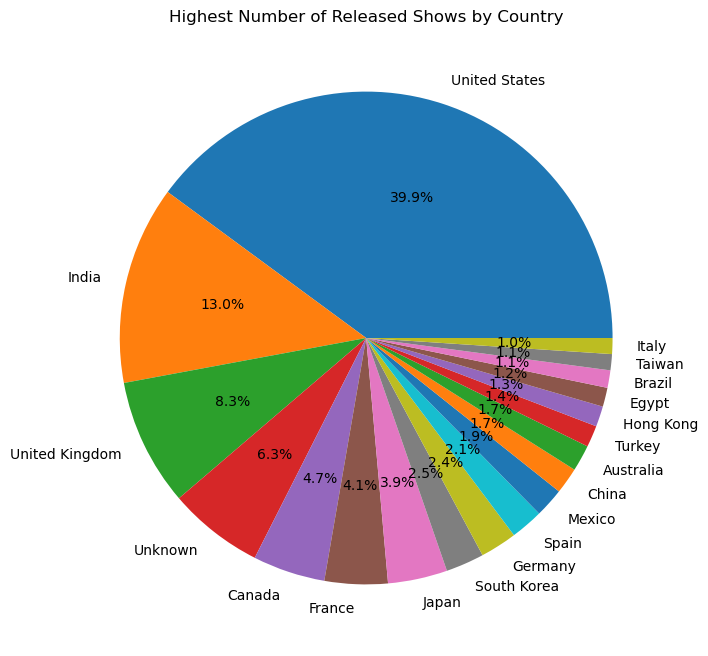

In [126]:
plt.figure(figsize=(10,8))
plt.pie(
    df_highcount['count'],
    labels = df_highcount['Country'],
    autopct = "%1.1f%%"
)
plt.title('Highest Number of Released Shows by Country')
plt.xticks(rotation = 90)
plt.show()


* This is a Pie chart Representing the Highest Total Shows Released by Nation/Country.
* USA has the Highest Number of Released Shows in Netflix Around 40%.
* Next is Holding India Around 13% but Compare to USA it's so low because India and USA have difference about more than 25%. That Much Huge Shows are Released By Country USA.
* The Third Position is UK (United Kingdom) is about 8.3%.
* Italy, Taiwan, Brazil are the near to Releasing Average Shows per Country. (Average is 70, Italian shows Releasing Netflix is == 70).

In [127]:
df_lowcount = df_country[df_country['count'] < 70].sort_values(by = 'count', ascending=False)
df_lowcount

,Country,count
19,Argentina,68
20,Indonesia,67
21,Nigeria,64
22,Philippines,63
23,Belgium,61
...,...,...
105,Cyprus,1
106,Kazakhstan,1
107,Malawi,1
108,Slovakia,1


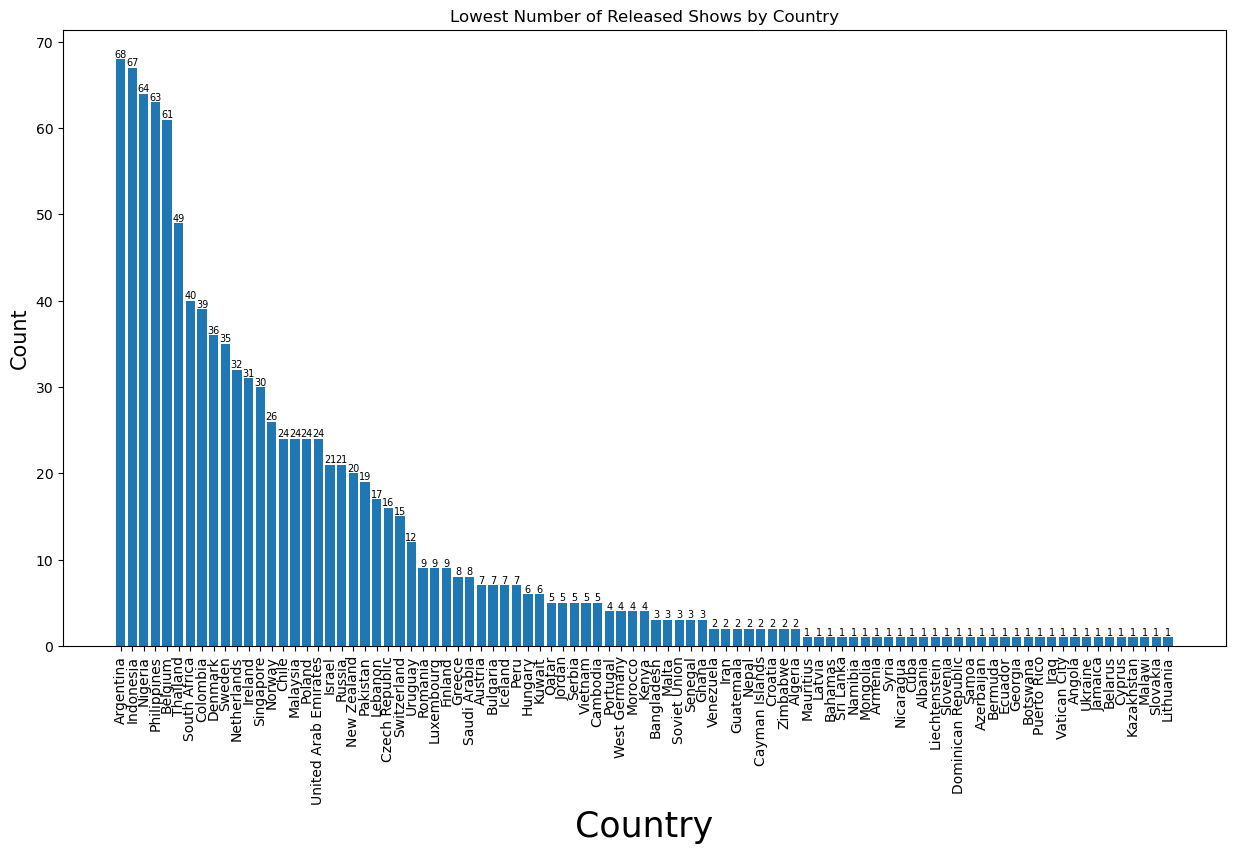

In [128]:
plt.figure(figsize=(15,8))
figs = plt.bar(
    df_lowcount['Country'],
    df_lowcount['count']
)
plt.bar_label(figs,fontsize = 7)
plt.title('Lowest Number of Released Shows by Country')
plt.xticks(rotation = 90)
plt.xlabel('Country',fontsize = 25)
plt.ylabel('Count',fontsize = 15)
plt.show()


* This is a Bar chart Representing the Lowest Total Shows Released by Nation/Country.
* Argentina has the Highest Number of Released Shows Among the Lowest Released Country in Netflix about 68.
* Next is Holding Indonesia Around 67 but Compare to Argentina it's Only 1 drop.
* The Third Position is Nigeria is about 64.
* Belgium, Philippines, Nigeria, Indonesia, Argentina are the most top 5 highest Released Shows Among the Lowest Show Released Country. They 5 are about 61 - 68 almost Near to Average
* Mauritius, Bahamas, Sri Lanka to Mongolia are the Most Lowest Released Shows in Netflix only 1

In [129]:
data_country['Release_Date'].isna().sum()

np.int64(98)

In [130]:
mean = data_country['Release_Date'].mean()

In [131]:
data_country['Release_Date'] = data_country['Release_Date'].fillna(mean)

In [132]:
data_country.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7786 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Show_Id       7786 non-null   object        
 1   Category      7786 non-null   object        
 2   Title         7786 non-null   object        
 3   Director      7786 non-null   object        
 4   Cast          7786 non-null   object        
 5   Country       7786 non-null   object        
 6   Release_Date  7786 non-null   datetime64[ns]
 7   Rating        7786 non-null   object        
 8   Duration      7786 non-null   object        
 9   Type          7786 non-null   object        
 10  Description   7786 non-null   object        
dtypes: datetime64[ns](1), object(10)
memory usage: 729.9+ KB


In [142]:
data_country.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description', 'month'],
      dtype='object')

In [143]:
data_country.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description,month
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,August
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,December
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",December
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",November
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,January


In [140]:
data_country['month'] = data_country['Release_Date'].dt.month_name()
# df_highcount['month'] = df_highcount['Date'].dt.month_name()

In [141]:
data_country.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description,month
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,August
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,December
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",December
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",November
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,January


In [144]:
data_country['Year'] = data_country['Release_Date'].dt.year


In [145]:
df_group = data_country.groupby(['Country', 'Year', 'month'])['Show_Id'].count().reset_index()
df_group

,Country,Year,month,Show_Id
0,Albania,2020,September,1
1,Algeria,2019,November,1
2,Algeria,2020,January,1
3,Angola,2020,January,1
4,Argentina,2016,December,3
...,...,...,...,...
1836,West Germany,2018,April,1
1837,West Germany,2019,December,1
1838,West Germany,2020,October,1
1839,Zimbabwe,2018,March,1


In [146]:
df_group = df_group.sort_values(by='Show_Id', ascending=False)
df_group

,Country,Year,month,Show_Id
1736,United States,2019,November,98
1729,United States,2019,December,83
1749,United States,2020,October,81
1743,United States,2020,January,79
1737,United States,2019,October,78
...,...,...,...,...
16,Argentina,2018,January,1
1825,Uruguay,2020,November,1
1815,Uruguay,2017,June,1
1816,Uruguay,2017,November,1


In [147]:
df_us = df_group[
(df_group['Country'] == 'United States')
]

In [148]:
df_us

,Country,Year,month,Show_Id
1736,United States,2019,November,98
1729,United States,2019,December,83
1749,United States,2020,October,81
1743,United States,2020,January,79
1737,United States,2019,October,78
...,...,...,...,...
1683,United States,2015,February,1
1684,United States,2015,January,1
1685,United States,2015,July,1
1686,United States,2015,June,1


In [149]:
# Define correct month order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Convert 'month' column into an ordered categorical
df_us['month'] = pd.Categorical(df_us['month'], categories=month_order, ordered=True)

# Sort by both Year and month order
df_us = df_us.sort_values(by=['Year', 'month']).reset_index(drop=True)

# Display the sorted DataFrame
df_us.head(15)

,Country,Year,month,Show_Id
0,United States,2008,February,1
1,United States,2009,May,1
2,United States,2010,November,1
3,United States,2011,September,1
4,United States,2011,October,5
5,United States,2013,March,1
6,United States,2013,August,1
7,United States,2013,December,1
8,United States,2014,January,1
9,United States,2014,February,2


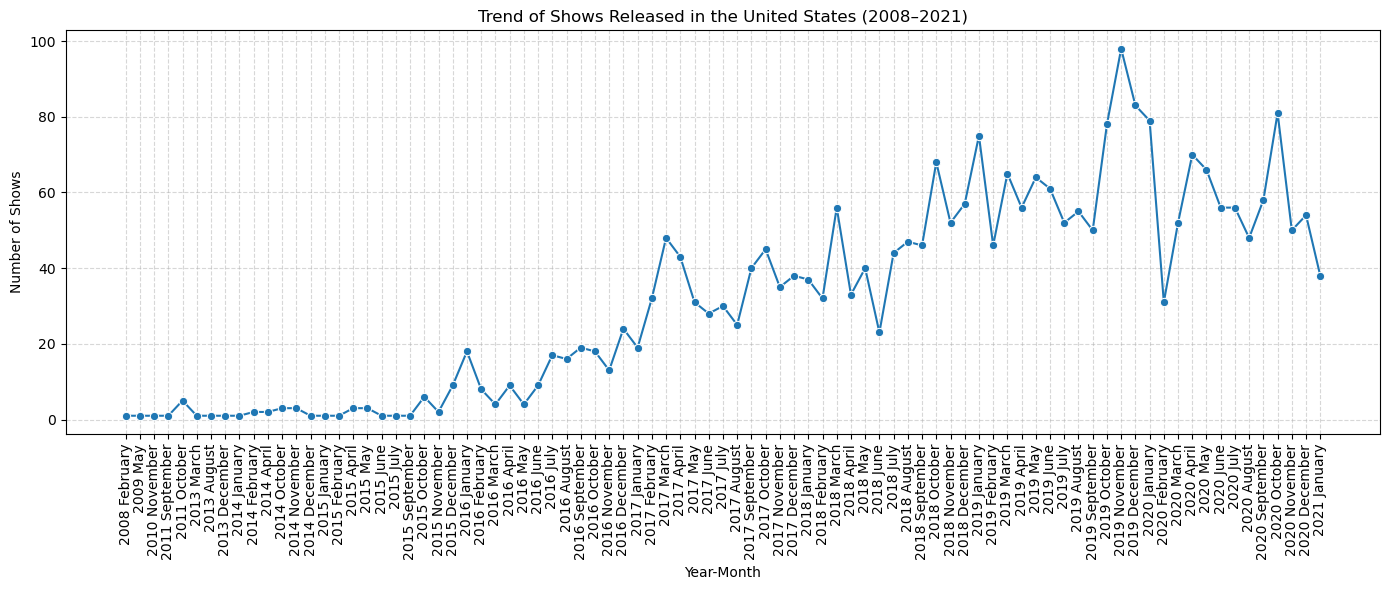

In [150]:
# Create a combined time column for better plotting
df_us['time'] = df_us['Year'].astype(str) + ' ' + df_us['month'].astype(str)

# Plot line chart
plt.figure(figsize=(14,6))
sns.lineplot(
    data=df_us,
    x='time',
    y='Show_Id',
    marker='o'
)

# Beautify chart
plt.xticks(rotation=90)
plt.title('Trend of Shows Released in the United States (2008–2021)')
plt.xlabel('Year-Month')
plt.ylabel('Number of Shows')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
data_country['Release_Date'] = pd.to_datetime(data_country['Release_Date'], errors='coerce')

# Extract Year and Month
data_country['Year'] = data_country['Release_Date'].dt.year
data_country['month'] = data_country['Release_Date'].dt.month_name()


In [164]:
df_highcount['month'] = data_country['Release_Date'].dt.month_name()
df_highcount['Show_Id'] = data_country['Show_Id']
df_highcount

,Country,count,Year,Month,month,Show_Id
0,United States,2682,2020,August,August,s1
1,India,875,2016,December,December,s2
2,United Kingdom,561,2018,December,December,s3
3,Unknown,421,2017,November,November,s4
4,Canada,319,2020,January,January,s5
5,France,278,2017,July,July,s6
6,Japan,262,2020,June,June,s7
7,South Korea,169,2019,November,November,s8
8,Germany,162,2019,April,April,s9
9,Spain,144,2017,December,December,s10


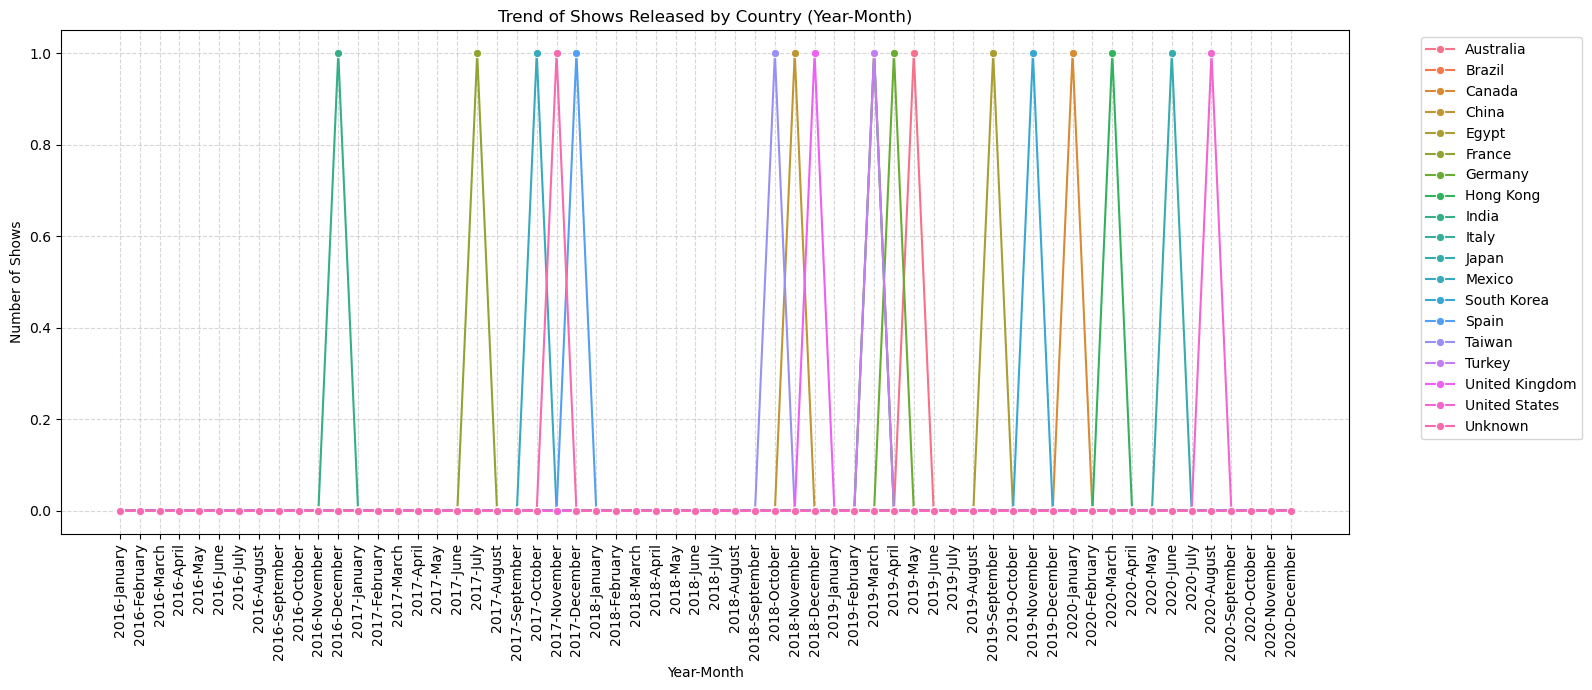

In [170]:
# Define correct month order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
df_highcount['month'] = pd.Categorical(df_highcount['month'], categories=month_order, ordered=True)

# Sort and group
trend = df_highcount.groupby(['Country', 'Year', 'month'])['Show_Id'].count().reset_index()
trend['time'] = trend['Year'].astype(str) + '-' + trend['month'].astype(str)
plt.figure(figsize=(16,7))
sns.lineplot(
    data=trend,
    x='time',
    y='Show_Id',
    hue='Country',
    marker='o',
    color = "Yellow"
)
plt.title('Trend of Shows Released by Country (Year-Month)')
plt.xlabel('Year-Month')
plt.ylabel('Number of Shows')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


In [ ]:
plt.figure(figsize = (8,5))
sns.barplot(
data = df_highcount,
x = 'Country',
y = 'Date',
hue = 'month'
)
plt.xticks(rotation = 90)
plt.legend(title = 'Month',bbox_to_anchor = (1,1))
plt.ylabel('Year')
plt.title('Most Shows were Released Based on Period')
plt.show()

* #### In USA - August Month on 2020 were Most Shows were Released.
* #### In India - December Month on 2017 Released Most Shows.
* #### In UK - November Month on 2018 Released Most Shows.
* #### In Canada - January Month on 2019 were Most Shows are Released.
* #### In France - July Month on 2017 were Released Most Shows.
* #### Here We See After 2015 were Most Shows are Released, That means Netflix Shows are Become Popular after 2015

In [62]:
direct = data_country['Director']

In [63]:
direct['Director'] = data_country['Director'].copy()

In [64]:
direct = direct['Director'].value_counts().reset_index()

In [65]:
direct = direct[direct['Director'] != 'Unknown']

In [66]:
direct

,Director,count
1,"Raúl Campos, Jan Suter",18
2,Marcus Raboy,16
3,Jay Karas,14
4,Cathy Garcia-Molina,13
5,Jay Chapman,12
...,...,...
4045,John Suits,1
4046,Shashanka Ghosh,1
4047,Paul Greengrass,1
4048,Swapnaneel Jayakar,1


In [67]:
direct['Director'] = direct['Director'].drop_duplicates(keep = 'first')

In [68]:
dir10 = direct.head(10)

In [69]:
dir10

,Director,count
1,"Raúl Campos, Jan Suter",18
2,Marcus Raboy,16
3,Jay Karas,14
4,Cathy Garcia-Molina,13
5,Jay Chapman,12
6,Youssef Chahine,12
7,Martin Scorsese,12
8,Steven Spielberg,10
9,David Dhawan,9
10,Johnnie To,8


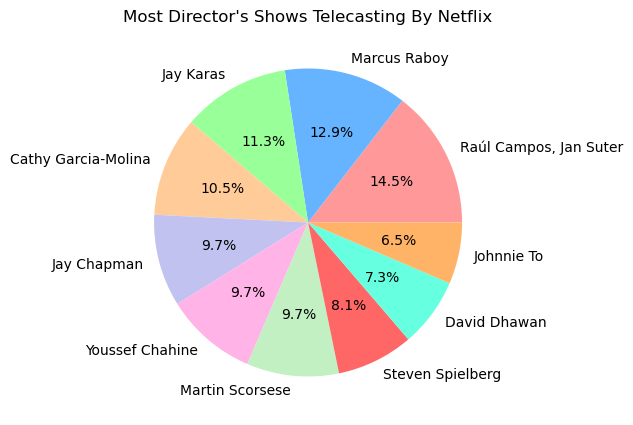

In [70]:
plt.figure(figsize = (9,5))
plt.pie(
    dir10['count'],
    labels = dir10['Director'],
    autopct = "%1.1f%%",
    colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6','#c2f0c2','#ff6666','#66ffe0','#ffb366']

)
plt.title("Most Director's Shows Telecasting By Netflix")
plt.show()

* #### These are the Most Directors films Which runs on Netflix.
* #### Jay Karas's films are the Most Number of Films Runs on Netflix around 13.9%
* #### Rauls Campos, Jan Suter Films are the Second Most Runs films in Netflix Around 12.7%.
* #### David Dhawan, Jay Chapman, Marcus Raboy's Films run By Netflix Around 10.1%.
* #### Steven Spielberg, Lance Bangs, Shannon Hartman and S.S Rajamouli films are the Third Position Which is 8.9%.
* #### Johnnie To Has the Last of Top 10 around 7.6% films in Netflix is directed by Him.

In [71]:
data_country['Cast'] = data_country['Cast'].str.split(',').explode('Cast')

In [72]:
data_country['Cast'] = data_country['Cast'].str.lstrip()

In [73]:
data_country.replace([''],np.nan, inplace = True)
data_country.dropna(subset = ['Cast'], inplace = True)
data_country.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,Unknown,João Miguel,Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,Bianca Comparato,Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,Michel Gomes,Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,Rodolfo Valente,United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,Vaneza Oliveira,United States,2020-01-01,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [74]:
# Split cast strings into lists
data_country['Cast_list'] = data_country['Cast'].str.split(', ')
from collections import Counter
cast_counter = Counter()

for cast_row in data_country['Cast_list']:
    if cast_row:  
        cast_counter.update(set(cast_row))
Top_cast = pd.DataFrame(cast_counter.items(), columns=['Cast', 'count'])
Top_cast = Top_cast.sort_values(by='count', ascending=False).reset_index(drop=True)
Top_cast


,Cast,count
0,Unknown,85
1,Takahiro Sakurai,8
2,Tamannaah Bhatia,8
3,Nassar,8
4,Yuki Kaji,8
...,...,...
6568,Ranvir Shorey,1
6569,Diana Penty,1
6570,Ande Cunningham,1
6571,Mark Mitchinson,1


In [75]:
Top_cast = Top_cast[
Top_cast['Cast'] != 'Unknown'
]

In [76]:
more_50 = Top_cast[
(Top_cast['count'] >= 4)
]

In [77]:
more_50

,Cast,count
1,Takahiro Sakurai,8
2,Tamannaah Bhatia,8
3,Nassar,8
4,Yuki Kaji,8
5,Prabhas,7
...,...,...
66,Lisa-Marie Koroll,4
67,Louis Held,4
68,Michael Maertens,4
69,Katsuyuki Konishi,4


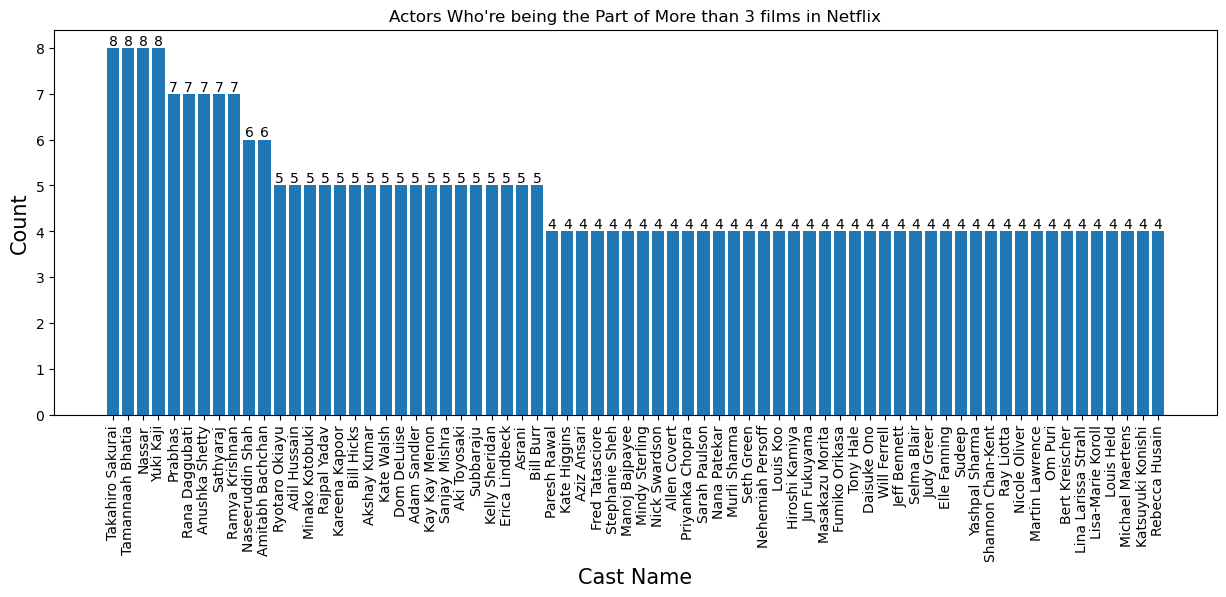

In [78]:
plt.figure(figsize = (15,5))
fig = plt.bar(
    more_50['Cast'],
    more_50['count'],
    
)
plt.bar_label(fig)
plt.xticks(rotation = 90)
plt.title("Actors Who're being the Part of More than 3 films in Netflix")
plt.xlabel('Cast Name',fontsize = 15)
plt.ylabel('Count',fontsize = 15)
plt.show()

* #### These are the Actors who're the Part of More than 4 Films in Netflix.
* #### Takahiro Sakurai, Tamannaah Bhatia, Nassar,Yuki Kaji are the Most Casted Actor in Netflix films Around 8 Films.
* #### Prabhas, Rana Dagubati, Anushka Shetty, Sathyaraj, Ramya Krishnan these Actor's Films was in Netflix, Around their 7 Films in Netflix Platform.
* #### Amitabh Bachan, Ryotaro okiayu have the third Most Casted Films in Netflix Platform - 6 Films.

In [79]:
top_cat = data_country['Rating'].value_counts(ascending = True).reset_index()
top_cat = top_cat[top_cat['Rating'] != 'Unknown']

In [80]:
top_cat

,Rating,count
0,NC-17,3
1,UR,5
2,TV-Y7-FV,6
4,G,39
5,NR,84
6,TV-G,194
7,PG,247
8,TV-Y7,270
9,TV-Y,280
10,PG-13,386


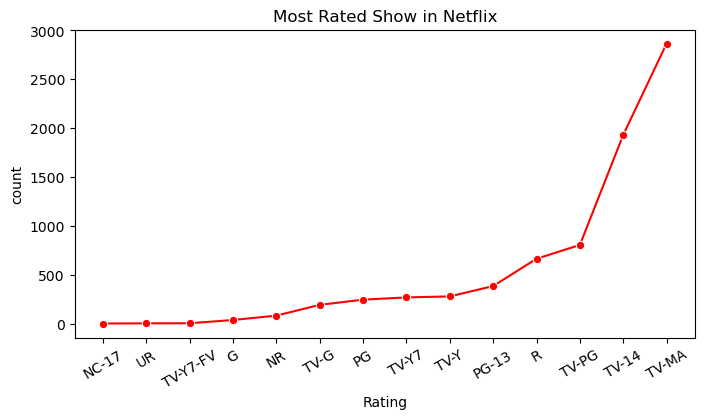

In [81]:
plt.figure(figsize = (8,4))
sns.lineplot(
    data = top_cat,
    x = 'Rating',
    y = 'count',
    marker = 'o',
    color = 'Red'
)
plt.title('Most Rated Show in Netflix')
plt.xticks(rotation = 30)
plt.show()

* #### Most Rated Show in Netflix (According to this Data) is TV-MA. Which Means a Program is Intended for Adults and May be unsuitable for Viewers Under 17. These Shows May Contain graphic Violence or Crude indecent languages.

* #### Second Most Rated Show in Netflix (According to this Data) is TV-14. Which Means a Television Program contains Material that parents are Strongly cautioned against letting children under the age of 14 watch, as it may be unsuitable for that age Group.

* #### Third Most Rated Show in Netflix (According to this Data) is TV-PG. Which Means 'Parental Guidance Suggested', A Television program Rating for content that may not b suitable for younger children. Program may contain mid violence, Language or mature themes.

* #### Most Lowest Rated Show in Netflix (According to this Data) is NC-17. Which Means a Film Rating for Movies that are not considered suitable for individuals under the Age of 17.
 
* #### According to this Data and Graph we can Understand that Most Films and Shows are not suitable for Younger Children it May suit for Adults, Because of the Show's Behaviour

In [82]:
data_country['Year'] = data_country['Release_Date'].dt.year

In [83]:
year = data_country['Year'].value_counts().reset_index()

In [84]:
year

,Year,count
0,2019,2233
1,2020,2009
2,2018,1661
3,2017,1200
4,2016,432
5,2021,117
6,2015,79
7,2014,24
8,2011,13
9,2013,10


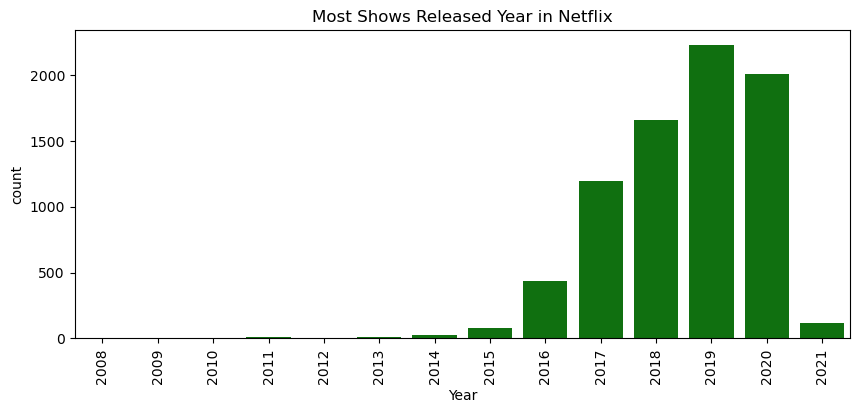

In [85]:
plt.figure(figsize = (10,4))
sns.barplot(
    data = year,
    x = 'Year',
    y = 'count',
    color = 'Green'
)
plt.title('Most Shows Released Year in Netflix')
plt.xticks(rotation = 90)
plt.show()

* #### Here the Most Shows Released Year Graph.
* #### The Most Shows are Released in 2019 and 2020.
* #### Around 2000 shows (each year) are Released in 2019 and 2020.
* #### The Second Most Shows are relased in 2018.
* #### Around 1750 Shows in a Year.

*  #### Overall the Data is Showing About the Release date, Year, Shows'name, their Director, and their Rating in Netflix.

These aren Visualization i found From this Data.